# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse

In [593]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [594]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd")

In [595]:
data.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
0,1,03/12/2025 02:18:46 AM,-32640.00,-32640.00,-32640.00,-32640.00,-32640.00,-32640.00
1,2,03/12/2025 02:19:16 AM,42.09,40.22,40.41,40.23,40.41,50.26
2,3,03/12/2025 02:19:46 AM,80.89,78.91,79.74,79.04,79.32,79.78
3,4,03/12/2025 02:20:16 AM,80.89,78.93,79.74,79.18,79.44,79.64
4,5,03/12/2025 02:20:46 AM,80.87,78.93,79.75,79.18,79.44,79.74


In [596]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    3678 non-null   int64  
 1   Time     3678 non-null   str    
 2   CH01(%)  3678 non-null   float64
 3   CH02(%)  3678 non-null   float64
 4   CH03(%)  3678 non-null   float64
 5   CH04(%)  3678 non-null   float64
 6   CH05(%)  3678 non-null   float64
 7   CH06(%)  3678 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 230.0 KB


In [597]:

# Convert Time column from string to datetime
data['Time'] = pd.to_datetime(data['Time'], format='mixed')

# Set Time as index for time series analysis
data = data.set_index('Time')


In [598]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3678 entries, 2025-03-12 02:18:46 to 2025-03-13 08:57:16
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    3678 non-null   int64  
 1   CH01(%)  3678 non-null   float64
 2   CH02(%)  3678 non-null   float64
 3   CH03(%)  3678 non-null   float64
 4   CH04(%)  3678 non-null   float64
 5   CH05(%)  3678 non-null   float64
 6   CH06(%)  3678 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 229.9 KB


In [599]:
data.index.is_monotonic_increasing

# If returns False, sort the index
# data = data.sort_index()

True

In [600]:
# Remove impossible humidity values
data = data.replace(-32640, pd.NA)

# Drop rows where all channels are missing
data = data.dropna(how='all')

In [601]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3678 entries, 2025-03-12 02:18:46 to 2025-03-13 08:57:16
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Index    3678 non-null   int64 
 1   CH01(%)  3677 non-null   object
 2   CH02(%)  3677 non-null   object
 3   CH03(%)  3677 non-null   object
 4   CH04(%)  3677 non-null   object
 5   CH05(%)  3677 non-null   object
 6   CH06(%)  3677 non-null   object
dtypes: int64(1), object(6)
memory usage: 229.9+ KB


In [602]:
data.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-03-12 02:18:46,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-03-12 02:19:16,2,42.09,40.22,40.41,40.23,40.41,50.26
2025-03-12 02:19:46,3,80.89,78.91,79.74,79.04,79.32,79.78
2025-03-12 02:20:16,4,80.89,78.93,79.74,79.18,79.44,79.64
2025-03-12 02:20:46,5,80.87,78.93,79.75,79.18,79.44,79.74


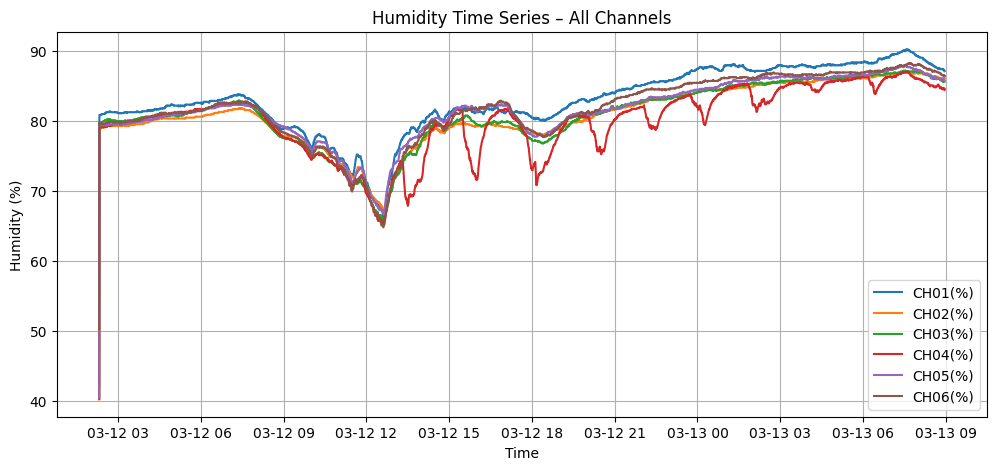

In [603]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
data = data.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
data = data.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [604]:
# Choose one channel
y = data['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest 30 minutes and aggregate duplicates
y.index = y.index.round('30min')
y = y.groupby(level=0).mean()

# Enforce strict 30-min frequency
y = y.asfreq('30min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]


In [605]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=569.081, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=240.469, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=240.140, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=237.840, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=236.883, Time=0.14 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=238.106, Time=0.21 sec
 ARIMA(1,0,5)(0,0,0)[0]             : AIC=237.078, Time=0.25 sec
 ARIMA(0,0,5)(

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   49
Model:               SARIMAX(2, 0, 4)   Log Likelihood                -105.466
Date:                Fri, 27 Mar 2026   AIC                            226.932
Time:                        16:48:13   BIC                            242.067
Sample:                    03-12-2025   HQIC                           232.674
                         - 03-13-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     20.3294      9.617      2.114      0.035       1.481      39.178
ar.L1          1.1389      0.360      3.162      0.002       0.433       1.845
ar.L2         -0.3965      0.317     -1.249      0.212      -1.019       0.226
ma.L1         -0.2748      0.305     -0.902      0.367      -0.872       0.322
ma.L2          0.2422      0.159      1.522      0.128      -0.070       0.554
ma.L3         -0.2348      0.139     -1.683      0.092      -0.508       0.039
ma.L4          0.6508      0.172      3.777      0.000       0.313       0.989
sigma2         4.0550      0.794      5.109      0.000       2.500       5.610
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                39.44
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               2.49   Skew:                             0.85
Prob(H) (two-sided):                  0.08   Kurtosis:                         7.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

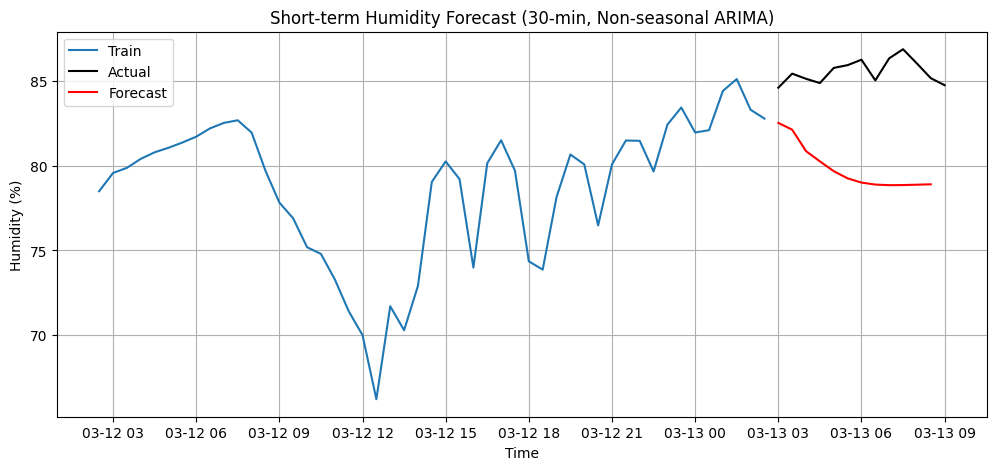

In [606]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='30min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (30-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


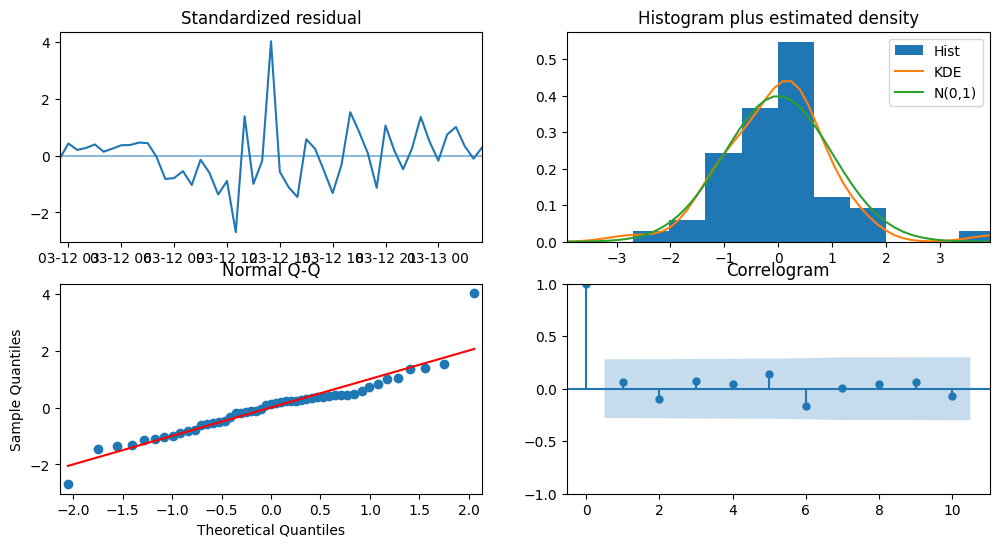

In [607]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [608]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 5.778955590545999
Simple  ARIMA(1,0,1) MAE: 5.616093614922292


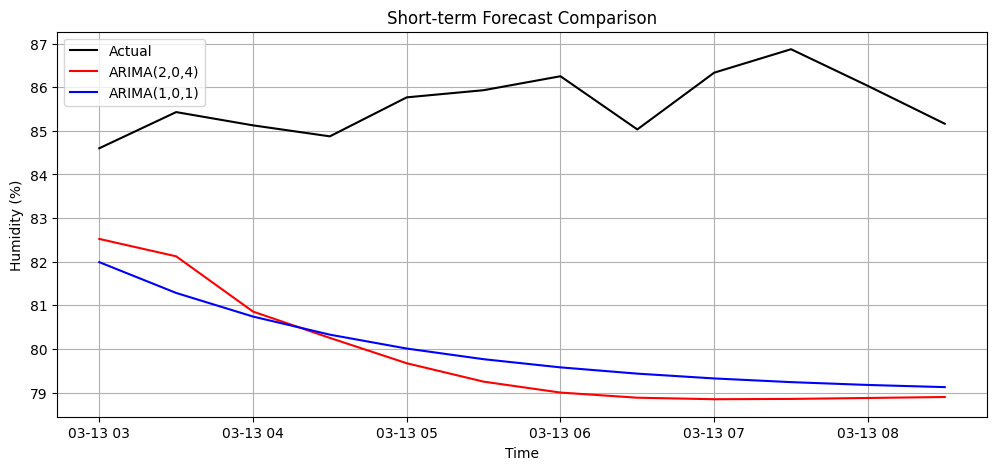

In [609]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
